In [1]:
import math, random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import numpy as np

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [30]:
# Define hyperparameters
IMG_SIZE = 32
EMBED_DIM = 64
ATTENTION_HEADS = 4
BATCH_SIZE = 12
EPOCHS = 10
LR = 0.001
TEMPERATURE = 0.07

### Dataset Creation & Preparation

In [23]:
# Define the possible colors, shapes, and positions for the synthetic dataset
colors = ['red', 'green', 'blue', 'yellow', 'purple', 'orange', 'pink', 'brown', 'gray']
shapes = ['square', 'circle', 'triangle']
positions = ['left', 'center', 'top', 'right', 'bottom', 'top-left', 'top-right', 'bottom-left', 'bottom-right']

In [24]:
# Function to draw an image with a specific color, shape, and position
def draw_img(color, shape, positions, img_size = IMG_SIZE):
    img = Image.new('RGB', (img_size, img_size), 'white')
    draw = ImageDraw.Draw(img)
    margin = 6
    w = h = img_size - 2 * margin

    if 'left' in positions:
        x0 = margin
        x1 = margin + w // 2
    elif 'top-left' in positions:
        x0 = margin
        x1 = margin + w // 2
    elif 'bottom-left' in positions:
        x0 = margin
        x1 = margin + w // 2
    elif 'right' in positions:
        x0 = margin + w // 2
        x1 = img_size - margin
    elif 'top-right' in positions:
        x0 = margin + w // 2
        x1 = img_size - margin
    elif 'bottom-right' in positions:
        x0 = margin + w // 2
        x1 = img_size - margin
    else:
        x0 = margin + w // 4
        x1 = margin + 3 * w // 4

    if 'top' in positions:
        y0 = margin
        y1 = margin + h // 2
    elif 'top-left' in positions:
        y0 = margin
        y1 = margin + h // 2
    elif 'top-right' in positions:
        y0 = margin
        y1 = margin + h // 2
    elif 'bottom' in positions:
        y0 = margin + h // 2
        y1 = img_size - margin
    elif 'bottom-left' in positions:
        y0 = margin + h // 2
        y1 = img_size - margin
    elif 'bottom-right' in positions:
        y0 = margin + h // 2
        y1 = img_size - margin
    else:
        y0 = margin + h // 4
        y1 = margin + 3 * h // 4

    if shape == 'square':
        draw.rectangle([x0, y0, x1, y1], fill=color, outline='black')
    elif shape == 'circle':
        draw.ellipse([x0, y0, x1, y1], fill=color, outline='black')
    elif shape == 'triangle':
        draw.polygon([(x0 + (x1 - x0) // 2, y0), (x0, y1), (x1, y1)], fill=color, outline='black')

    return img

In [25]:
# Define the ShapeDataset class to generate synthetic images and captions
class ShapeDataset():
    def __init__(self):
        self.images = []
        self.captions = []

        for c in colors:
            for s in shapes:
                for p in positions:
                    img = draw_img(c, s, p)
                    caption = f"{c} {s} {p}"

                    self.images.append(torch.from_numpy(np.asarray(img)).permute(2, 0, 1).float() / 255.0)
                    self.captions.append(caption)


        self.vocab, self.word2idx = self.build_vocab(self.captions)


    def build_vocab(self, texts):
        words = sorted({w for t in texts for w in t.split()})
        vocab = ['[CLS]'] + words
        w2i = {w:i for i, w in enumerate(vocab)}
        return vocab, w2i


    def encode_text(self, text):
        tokens = [self.word2idx['[CLS]']] + [self.word2idx[w] for w in text.split()]
        return torch.tensor(tokens, dtype = torch.long)


    def __getitem__(self, idx):
        return self.images[idx], self.encode_text(self.captions[idx])


    def __len__(self):
        return len(self.images)

In [33]:
# Create the dataset and print its vocabulary and length
dataset = ShapeDataset()
vocab = dataset.vocab
VOCAB_SIZE = len(vocab)
print(VOCAB_SIZE)
print(vocab)
len(dataset)

22
['[CLS]', 'blue', 'bottom', 'bottom-left', 'bottom-right', 'brown', 'center', 'circle', 'gray', 'green', 'left', 'orange', 'pink', 'purple', 'red', 'right', 'square', 'top', 'top-left', 'top-right', 'triangle', 'yellow']


243

In [27]:
# Split the dataset into training and testing sets
train_size = (int) (0.8 * len(dataset))
test_size = len(dataset) - train_size

train_set, test_set = torch.utils.data.random_split(dataset, [train_size, test_size])
print(len(train_set))
print(len(test_set))

194
49


In [28]:
# Create DataLoaders for the training and testing sets
train_loader = DataLoader(dataset=train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_set, batch_size=BATCH_SIZE, shuffle=False)

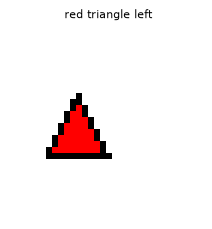

In [29]:
# Visualize a random image and its corresponding caption from the training set
imgs, encoded_caps = next(iter(train_loader))
idx = random.randint(0, len(imgs) - 1)
img = (imgs[idx].permute(1, 2, 0).numpy() * 255).astype(np.uint8)

caption_tokens = encoded_caps[idx].tolist()
caption = " ".join(dataset.vocab[token] for token in caption_tokens if token in range(len(dataset.vocab)))
caption = caption.replace('[CLS]', '')

plt.figure(figsize=(2.5, 2.5))
plt.imshow(img)
plt.title(caption, fontsize=8)
plt.axis('off')
plt.show()

### Model Architecture 

In [ ]:
# Image Encoder: A simple CNN to extract features from the input images
class ImageEncoder(nn.Module):
    def __init__(self, embed_dim = EMBED_DIM):
        super().__init__()

        self.convolutions = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(128, 256, 3, 2, 1),
            nn.ReLU()
        )

        self.projection = nn.Linear(256, embed_dim)
        self.layer_norm = nn.LayerNorm(embed_dim)


    def forward(self, X):
        out = self.convolutions(X)
        out = out.mean(dim=[2,3])
        out = self.projection(out)
        out = F.normalize(self.layer_norm(out), dim=-1)

        return out

In [ ]:
# Text Encoder
class TextEncoder(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, num_heads=ATTENTION_HEADS, context_window=4):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.position_embedding = nn.Embedding(context_window, embed_dim)
        self.mha = nn.MultiheadAttention(embed_dim, num_heads)
        self.projection_layer = nn.Linear(embed_dim, embed_dim)
        self.layer_norm = nn.LayerNorm(embed_dim)


    def forward(self, tokens):
        N, L = tokens.shape
        pos_emb_ids = torch.arrange(L, device=tokens.device()).unsqueeze(0).expand(N, L)
        pos_emb_vectors = self.position_embedding(pos_emb_ids)
        token_emb_vectors = self.token_embedding(tokens)
        final_embedding = token_emb_vectors + pos_emb_vectors
        context_vector = self.mha(final_embedding, final_embedding, final_embedding)[0]
        final_tokens = context_vector[:, 0]
        projection = self.projection_layer(final_tokens)
        output = F.normalize(self.layer_norm(projection), dim=-1)

        return output